In [ ]:
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True)

*Loading* *datasets*

In [ ]:
stellar_mass = [0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4]
stellar_luminosity = [0.15, 0.35, 1.00, 2.30, 4.10, 7.00, 11.2, 17.5, 25.0, 35.0]

# Dataset Visualization


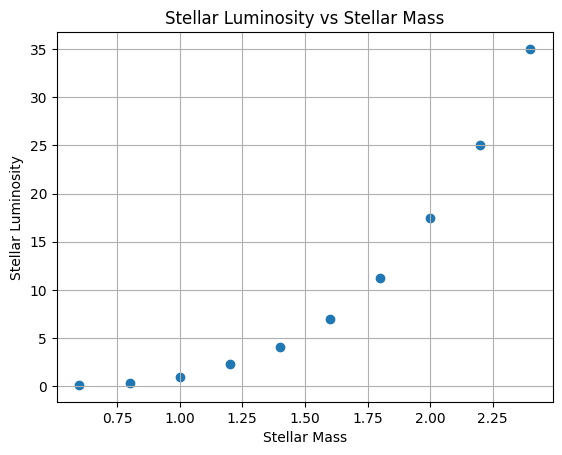

In [ ]:
plt.scatter(stellar_mass, stellar_luminosity)
plt.xlabel("Stellar Mass")
plt.ylabel("Stellar Luminosity")
plt.title("Stellar Luminosity vs Stellar Mass")
plt.grid(True)
plt.show()

# Model and Loss

In [ ]:
def predict(x, w, b):
    return w * x + b

def compute_cost(x, y, w, b):
    m = x.shape[0]
    y_hat = w * x + b
    errors = y_hat - y
    cost = (1 / (2 * m)) * np.sum(errors ** 2)
    return cost


For testing, we are going to estimate w and b and analyze the results.
We are going to calculte a mean slope and see the cost of our predictment.

w1 = (25 - 17.5) / (2.2 - 2) = 37.5
w2 = (35 - 25)/ (2.4 - 2.2) = 50
wmean = 43.75

Now, just for eye we can notice that when stellar mass = 0, its luminosity can't be > 0.15 so for this case b = 0

In [ ]:
w_test = 43.75
b_test = 0.0
y_hat_test = predict(np.array(stellar_mass), w_test, b_test)
print("predictions with w=43.75, b=0:", y_hat_test)
print("Cost with w=43.75, b=0:", compute_cost(np.array(stellar_mass),
np.array(stellar_luminosity), w_test, b_test))

predictions with w=43.75, b=0: [ 26.25  35.    43.75  52.5   61.25  70.    78.75  87.5   96.25 105.  ]
Cost with w=43.75, b=0: 1645.2061250000004


In conclusion, w = 43.75 is not a good start because the error rate is mor than 100% due to the relationship between stellar mass and luminosity is not linear

# Cost Surface

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

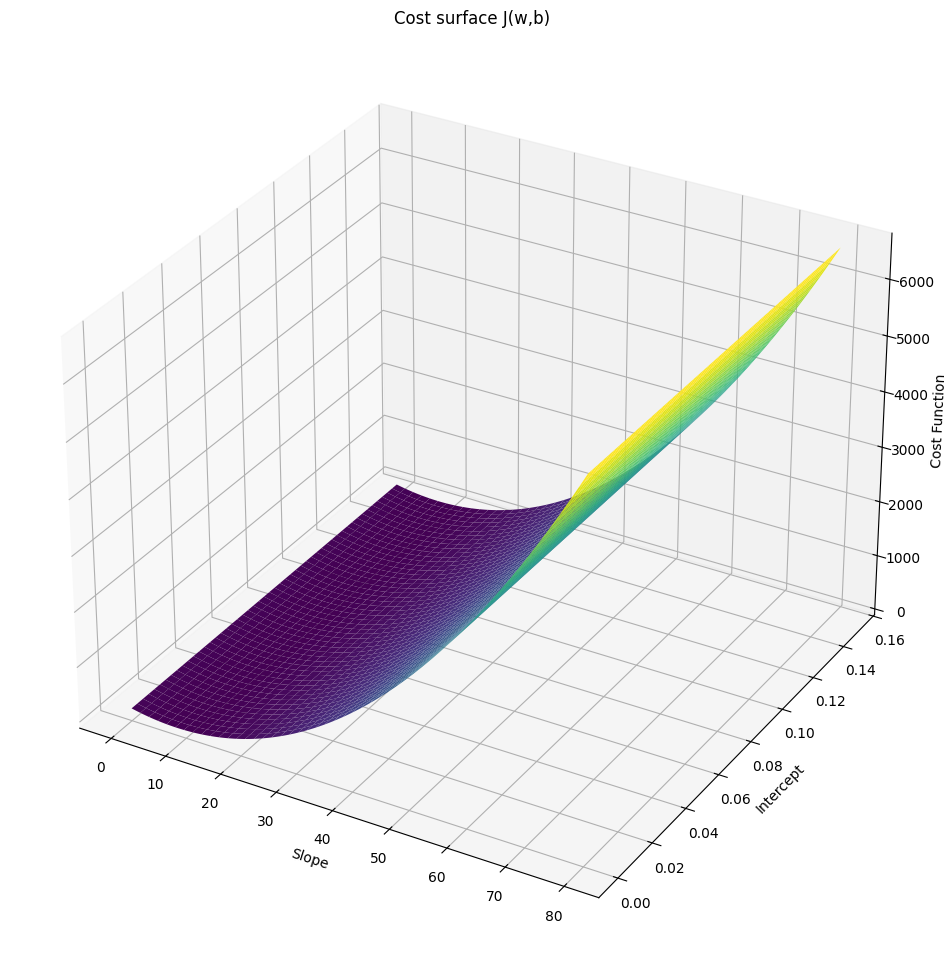

In [ ]:
w_values = np.linspace(0, 80, 1000) # By eye we can determine that the slope can't be greater tha 0.1
b_values = np.linspace(0, 0.15, 1000) # b < 0.6

W, B = np.meshgrid(w_values, b_values)
J_vals = np.zeros_like(W)
for i in range(W.shape[0]):
    for j in range(W.shape[1]):
        J_vals[i, j] = compute_cost(np.array(stellar_mass),
        np.array(stellar_luminosity), W[i, j], B[i, j])

fig = plt.figure(figsize=(12,12))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(W, B, J_vals, cmap=cm.viridis, linewidth=0, antialiased=True)
ax.set_xlabel("Slope")
ax.set_ylabel("Intercept")
ax.set_zlabel("Cost Function")
ax.set_title("Cost surface J(w,b)")
plt.show()

What we can conclude about the surface is that meanwhile slope and intercep increase, the cost increase too

In [ ]:
# Calculate Minimum Cost
cost_min = np.min(J_vals)

# Calculate (i,j) of the minimum cost
i_min, j_min = np.unravel_index(np.argmin(J_vals), J_vals.shape)

# Calculate w and b according to the minimum cost
w_min = W[i_min, j_min]
b_min = B[i_min, j_min]

print("J_min:", cost_min)
print("w_min:", w_min)
print("b_min:", b_min)


J_min: 27.921897429712
w_min: 8.328328328328329
b_min: 0.0


# Gradients

In [ ]:
def compute_gradients(x, y, w, b):
    m = x.shape[0]
    y_hat = w * x + b
    errors = y_hat - y
    dj_dw = (1 / m) * np.sum(errors * x)
    dj_db = (1 / m) * np.sum(errors)
    return dj_dw, dj_db

# Gradient descent


In [ ]:

def gradient_descent(x, y, w_init, b_init, alpha, num_iterations):
    w = w_init
    b = b_init
    history = []

    for i in range(num_iterations):
        dj_dw, dj_db = compute_gradients(x, y, w, b)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        cost = compute_cost(x, y, w, b)
        history.append((i, cost))
    return w, b, history

For this study case, we are going to start with a learning rate of 0.01 and do 2000 iterations to see the results. In this case w and b are going to be 0 beacuse the prediction is automatized.

In [ ]:
alpha = 0.01
num_iterations = 2000

w_init = 0.0
b_init = 0.0

w_learned, b_learned, history = gradient_descent(np.array(stellar_luminosity), np.array(stellar_mass), w_init, b_init, alpha, num_iterations)
print("\nLearned parameters:")
print("w =", w_learned)
print("b =", b_learned)


Learned parameters:
w = -1.2114808828494722e+265
b = -5.344225915124378e+263


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/tmp/ipython-input-63329435.py:8: RuntimeWarning: overflow encountered in square
  cost = (1 / (2 * m)) * np.sum(errors ** 2)


For a learning rate of α = 0.01, the cost increases rapidly and numerical overflow occurs during the computation of the squared errors.

# Converge


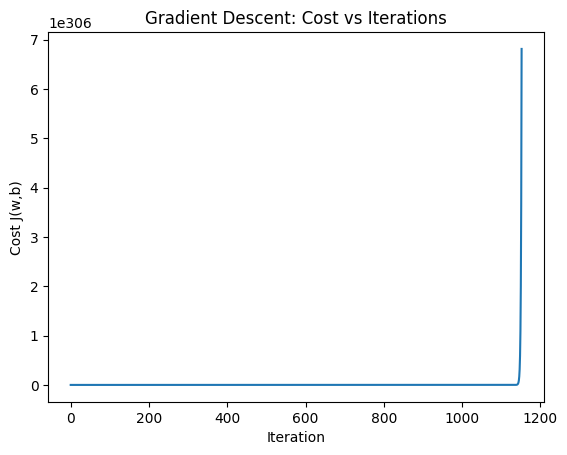

In [ ]:
iterations = [it for it, c in history]
costs = [c for it, c in history]
plt.figure()
plt.plot(iterations, costs)
plt.xlabel("Iteration")
plt.ylabel("Cost J(w,b)")
plt.title("Gradient Descent: Cost vs Iterations")
plt.show()

With α=0.01, the loss does not decrease over iterations; instead, it eventually grows explosively, indicating divergence rather than convergence. Therefore, there is no meaningful convergence speed to report. The optimization is unstable, consistent with an overly large learning rate that causes overshooting and numerical instability. For this reason is important to decrease the learning rate

# Eperiments


## α = 0.001

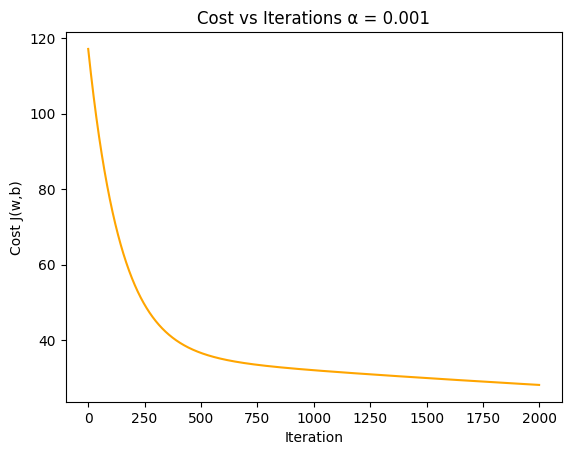

In [ ]:
alpha = 0.001
w_learned, b_learned, history = gradient_descent(np.array(stellar_mass), np.array(stellar_luminosity), w_init, b_init, alpha, num_iterations)

iterations = [it for it, c in history]
costs = [c for it, c in history]
plt.figure()
plt.plot(iterations, costs, color="orange")
plt.xlabel("Iteration")
plt.ylabel("Cost J(w,b)")
plt.title("Cost vs Iterations α = 0.001")
plt.show()

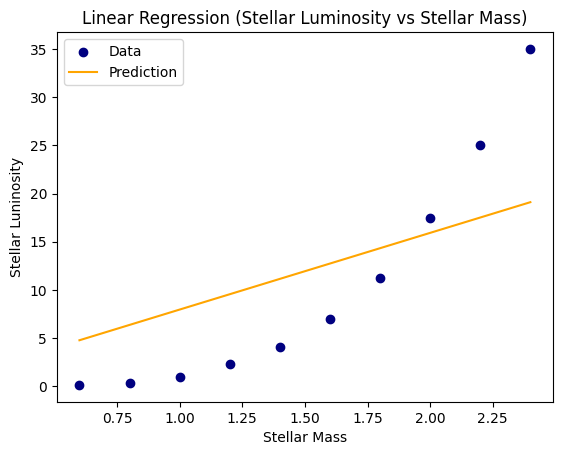


Learned parameters:
w = 7.95618583813993
b = 0.009567454004411478
Cost α=0.001: 7281.132703482825


In [ ]:
plt.figure()
plt.scatter(np.array(stellar_mass), np.array(stellar_luminosity), label="Data", color="navy")
y_pred = predict(np.array(stellar_mass), w_learned, b_learned)
plt.plot(np.array(stellar_mass), y_pred, label="Prediction", color = "orange")
plt.xlabel("Stellar Mass")
plt.ylabel("Stellar Luninosity")
plt.title("Linear Regression (Stellar Luminosity vs Stellar Mass)")
plt.legend()
plt.show()
print("\nLearned parameters:")
print("w =", w_learned)
print("b =", b_learned)
print("Cost α=0.001:",compute_cost(np.array(stellar_luminosity), np.array(stellar_mass),w_learned,b_learned))

## α = 0.002

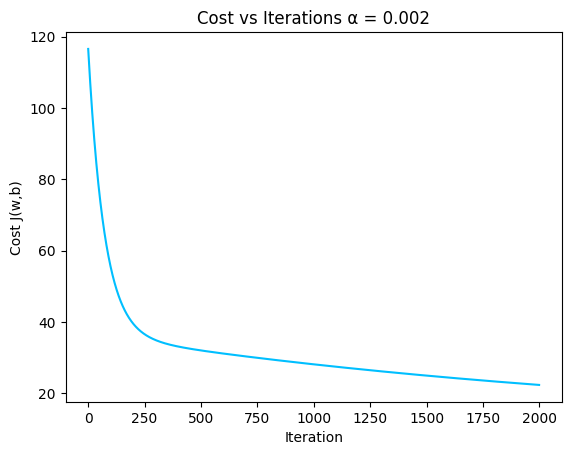

In [ ]:
alpha = 0.002
w_learned, b_learned, history = gradient_descent(np.array(stellar_mass), np.array(stellar_luminosity), w_init, b_init, alpha, num_iterations)

iterations = [it for it, c in history]
costs = [c for it, c in history]
plt.figure()
plt.plot(iterations, costs, color="deepskyblue")
plt.xlabel("Iteration")
plt.ylabel("Cost J(w,b)")
plt.title("Cost vs Iterations α = 0.002")
plt.show()

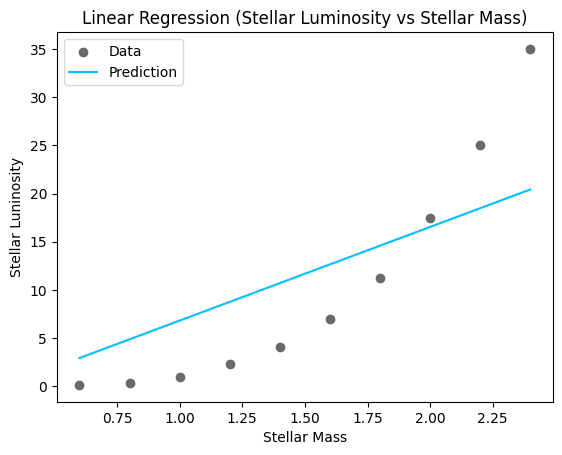


Learned parameters:
w = 9.71609230380018
b = -2.894144548583343
Cost α=0.002: 10620.240440095333


In [ ]:
plt.figure()
plt.scatter(np.array(stellar_mass), np.array(stellar_luminosity), label="Data", color="dimgray")
y_pred = predict(np.array(stellar_mass), w_learned, b_learned)
plt.plot(np.array(stellar_mass), y_pred, label="Prediction", color = "deepskyblue")
plt.xlabel("Stellar Mass")
plt.ylabel("Stellar Luninosity")
plt.title("Linear Regression (Stellar Luminosity vs Stellar Mass)")
plt.legend()
plt.show()

print("\nLearned parameters:")
print("w =", w_learned)
print("b =", b_learned)
print("Cost α=0.002:",compute_cost(np.array(stellar_luminosity), np.array(stellar_mass),w_learned,b_learned))




## α = 0.0001

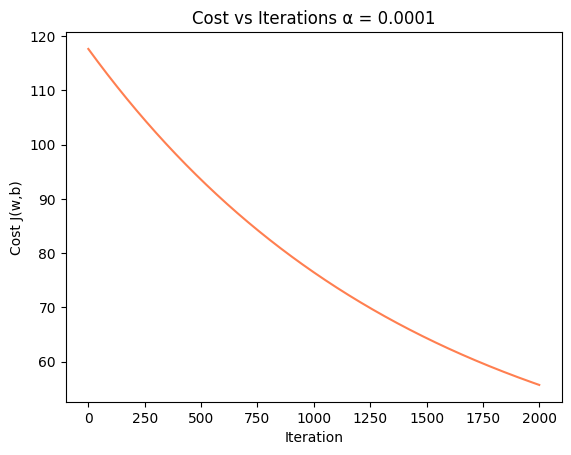

In [ ]:
alpha = 0.0001
w_learned, b_learned, history = gradient_descent(np.array(stellar_mass), np.array(stellar_luminosity), w_init, b_init, alpha, num_iterations)

iterations = [it for it, c in history]
costs = [c for it, c in history]
plt.figure()
plt.plot(iterations, costs, color="coral")
plt.xlabel("Iteration")
plt.ylabel("Cost J(w,b)")
plt.title("Cost vs Iterations α = 0.0001")
plt.show()

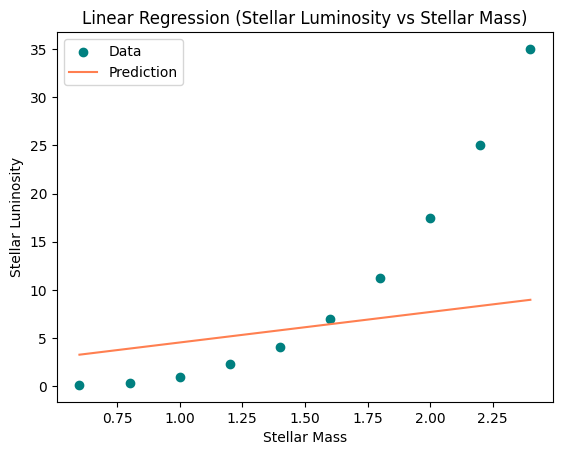


Learned parameters:
w = 3.1630361982290838
b = 1.38796195986714
Cost α=0.001: 1155.1076579698988


In [ ]:
plt.figure()
plt.scatter(np.array(stellar_mass), np.array(stellar_luminosity), label="Data", color="teal")
y_pred = predict(np.array(stellar_mass), w_learned, b_learned)
plt.plot(np.array(stellar_mass), y_pred, label="Prediction", color = "coral")
plt.xlabel("Stellar Mass")
plt.ylabel("Stellar Luninosity")
plt.title("Linear Regression (Stellar Luminosity vs Stellar Mass)")
plt.legend()
plt.show()
print("\nLearned parameters:")
print("w =", w_learned)
print("b =", b_learned)
print("Cost α=0.001:",compute_cost(np.array(stellar_luminosity), np.array(stellar_mass),w_learned,b_learned))

## Conclusion
For this dataset, non of this learning rates are the best because everytime that it is decrease, the error increments. This happen because the relationship between stellar mass and luminosity is not linear

# Conceptual Questions

*   **Astrophysical meaning of w:** w indicates the rate of change of the stellar mass with respect to its luminosity
*   **Why is a linear model limited here?:** Beacuse the relationship between stellar luminosity and stellar mass is not linear, so always the prediction will have a high error rate.

